# f11 GATS (spatial autocorrelation) → PCA & how many components

Group **f11_spatial_autocorrelation** uses Dragon columns whose names start with **`GATS`** (~48 in your matrix).

Same workflow as the other block notebooks: **standardize → PCA → cumulative variance plot** and **`k80`** (components needed for ~80% variance in this block).

**Data:** `data/waka_dragon_merged.csv`

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

csv_path = Path("data/waka_dragon_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(f"Put merged CSV here: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print("rows, cols:", df.shape)

rows, cols: (312, 2499)


### Step 1 — Keep only GATS columns

Same rule as `features_set_1.ipynb`: names starting with **`GATS`**.

In [3]:
block_cols = [c for c in df.columns if c.startswith("GATS")]
print("number of GATS descriptors:", len(block_cols))

X = df[block_cols].apply(pd.to_numeric, errors="coerce")
X = X.dropna(how="all")
print("samples after dropna(all):", len(X))

number of GATS descriptors: 48
samples after dropna(all): 288


### Step 2 — Standardize

In [4]:
X_filled = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
Xz = scaler.fit_transform(X_filled)
print("scaled matrix shape:", Xz.shape)

scaled matrix shape: (288, 48)


### Step 3 — Cumulative variance (how many PCs?)

With only ~48 inputs, **`k80`** is often small (sometimes **all** components are needed to reach 80% if the curve rises slowly — the plot shows this).

Smallest k with cumulative variance >= 80%: k80 = 9


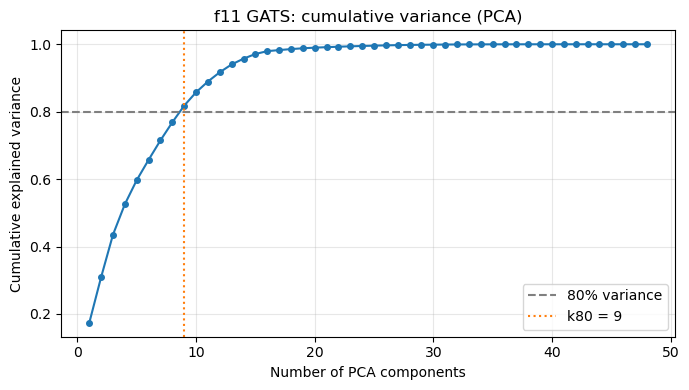

First 1 PC(s): 17.4% variance
First 2 PC(s): 30.9% variance
First 3 PC(s): 43.5% variance
First 5 PC(s): 59.7% variance
First 10 PC(s): 85.7% variance
First k80=9 PC(s): 81.8% variance


In [5]:
n_samples, n_features = Xz.shape
n_pca = min(80, n_samples - 1, n_features)

pca_explore = PCA(n_components=n_pca, random_state=0)
pca_explore.fit(Xz)

var_ratio = pca_explore.explained_variance_ratio_
cumsum = var_ratio.cumsum()

k80 = next((i + 1 for i, v in enumerate(cumsum) if v >= 0.8), len(cumsum))
print(f"Smallest k with cumulative variance >= 80%: k80 = {k80}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumsum) + 1), cumsum, marker="o", markersize=4)
ax.axhline(0.8, color="gray", linestyle="--", label="80% variance")
if k80 <= len(cumsum):
    ax.axvline(k80, color="C1", linestyle=":", label=f"k80 = {k80}")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("f11 GATS: cumulative variance (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k in (1, 2, 3, 5, 10):
    if k <= len(cumsum):
        print(f"First {k} PC(s): {cumsum[k-1]*100:.1f}% variance")
print(f"First k80={k80} PC(s): {cumsum[k80-1]*100:.1f}% variance")

### Step 4 — Export PCA scores

Prefix **`GATS_PC`** for this block.

In [6]:
n_keep = k80

pca_scores = PCA(n_components=n_keep, random_state=0)
scores = pca_scores.fit_transform(Xz)

out = pd.DataFrame(
    scores,
    columns=[f"GATS_PC{i+1}" for i in range(n_keep)],
    index=X.index,
)
if "CID" in df.columns:
    out.insert(0, "CID", df.loc[X.index, "CID"].values)

out.head()

,CID,GATS_PC1,GATS_PC2,GATS_PC3,GATS_PC4,GATS_PC5,GATS_PC6,GATS_PC7,GATS_PC8,GATS_PC9
0,179,-6.108475,0.734582,7.471650,-5.023694,-0.876451,-0.526934,-0.959659,-3.862348,-5.520581
1,240,-2.418559,-5.134104,0.776314,-2.128471,-7.932780,0.628478,1.450591,-1.364267,0.289503
2,244,-4.217149,-2.914131,2.109139,-2.701878,-3.260515,1.241513,3.004475,-1.159929,1.979703
3,323,-1.453849,-4.110220,-1.977443,-0.111195,-4.246247,1.754413,-1.024550,3.469755,-0.658883
4,326,-0.214389,0.597073,-4.289496,-2.939437,-0.443040,-5.578131,0.859086,1.290229,1.355786


### Step 5 (optional) — Top loadings on GATS_PC1

In [7]:
loadings = pd.DataFrame(
    pca_scores.components_.T,
    index=block_cols,
    columns=[f"GATS_PC{i+1}" for i in range(n_keep)],
)
col1 = loadings.columns[0]
top = loadings[col1].abs().sort_values(ascending=False).head(15)
print(f"Top 15 |loading| on {col1}:")
print(loadings.loc[top.index, col1])

Top 15 |loading| on GATS_PC1:
GATS2v    0.233170
GATS8v    0.227840
GATS8i    0.222183
GATS2p    0.221822
GATS8p    0.221698
GATS2i    0.216371
GATS8m    0.214471
GATS3v   -0.203824
GATS3m   -0.202095
GATS6i    0.199195
GATS6p    0.193118
GATS6v    0.191440
GATS3p   -0.185017
GATS3i   -0.184802
GATS1s   -0.175190
Name: GATS_PC1, dtype: float64


**Recap:** For a small block like GATS, **`k80`** may be a large fraction of the original 48 columns — that is normal. You can still choose a smaller **`n_keep`** for modeling and validate with cross-validation.